# Task 2: Unemployment Analysis with Python

## Objective
To analyze unemployment rate data using Python, explore unemployment trends,
study the impact of COVID-19, and identify important patterns or seasonal trends
through data cleaning, analysis, and visualization.

# **Import Required Libraries**

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load the Dataset**

In [5]:

from google.colab import files

print("Please upload the 'Unemployment_Rate_upto_11_2020.csv' file.")
uploaded = files.upload()

# Assuming the file is uploaded with the name 'Unemployment in India (1).csv' based on kernel state
df = pd.read_csv('/content/Unemployment in India (1).csv')

df.head()

Please upload the 'Unemployment_Rate_upto_11_2020.csv' file.


Saving Unemployment in India.csv to Unemployment in India.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# **Dataset Information**

In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


# **Check Missing Values**

In [7]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


# **Remove Missing Values**

In [8]:
df = df.dropna()

df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


# **Dataset Description**

In [9]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


# **Unemployment Rate Distribution**

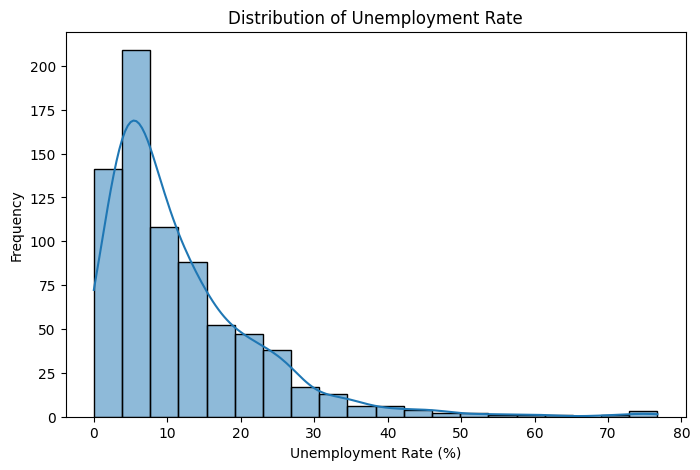

In [11]:
df.columns = df.columns.str.strip()

plt.figure(figsize=(8, 5))

sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

The unemployment rate is concentrated mainly at lower values, while higher unemployment rates occur less frequently.

# **Unemployment Rate by Area**


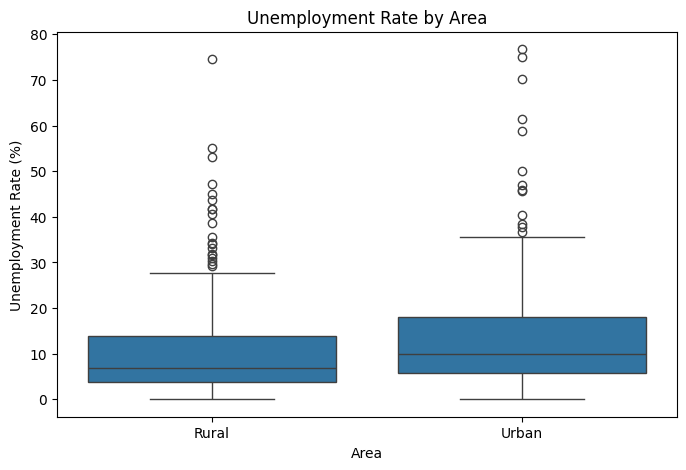

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)

plt.title("Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")

plt.show()

The box plot shows that urban areas have a somewhat higher typical unemployment rate than rural areas, with high-value outliers present in both areas.

# **Average Unemployment Rate by Area**

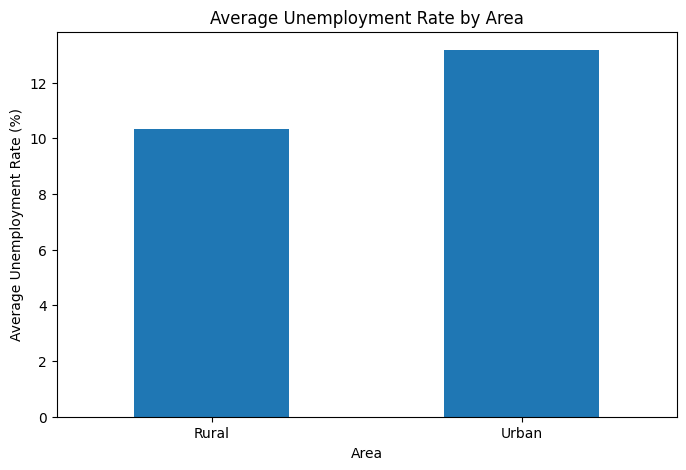

In [13]:
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8, 5))

area_avg.plot(kind='bar')

plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.show()

The average unemployment rate is higher in urban areas than in rural areas.

# **Unemployment Rate Trend Over Time**

/tmp/ipykernel_9304/3638379692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


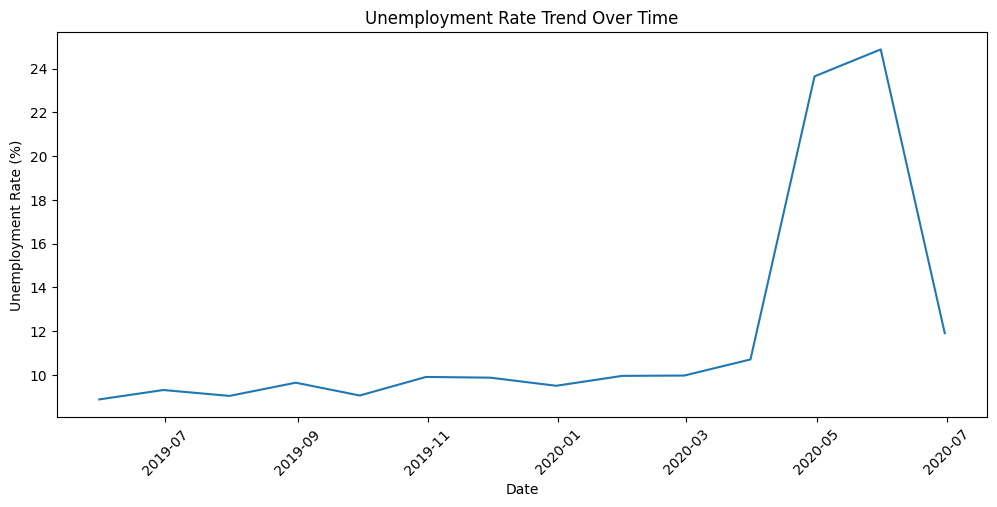

In [14]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 5))

plt.plot(monthly_avg.index, monthly_avg.values)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

The unemployment rate remained relatively stable during 2019 and early 2020, followed by a sharp increase around April–June 2020.

# **COVID-19 Impact Analysis**

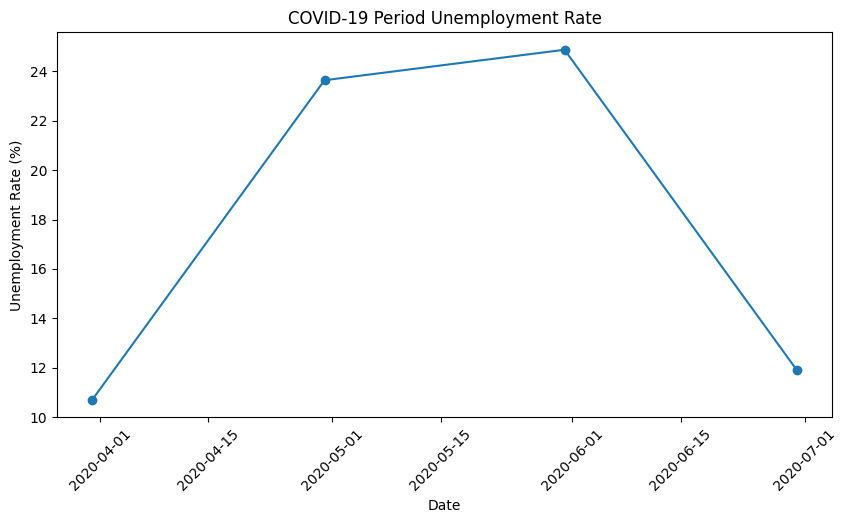

In [15]:
covid_period = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-06-30')
]

covid_avg = covid_period.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10, 5))

plt.plot(covid_avg.index, covid_avg.values, marker='o')

plt.title("COVID-19 Period Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

During the COVID-19 period, unemployment increased sharply from April to June 2020, followed by a decline in the next recorded period.

# **Unemployment Rate by Region**

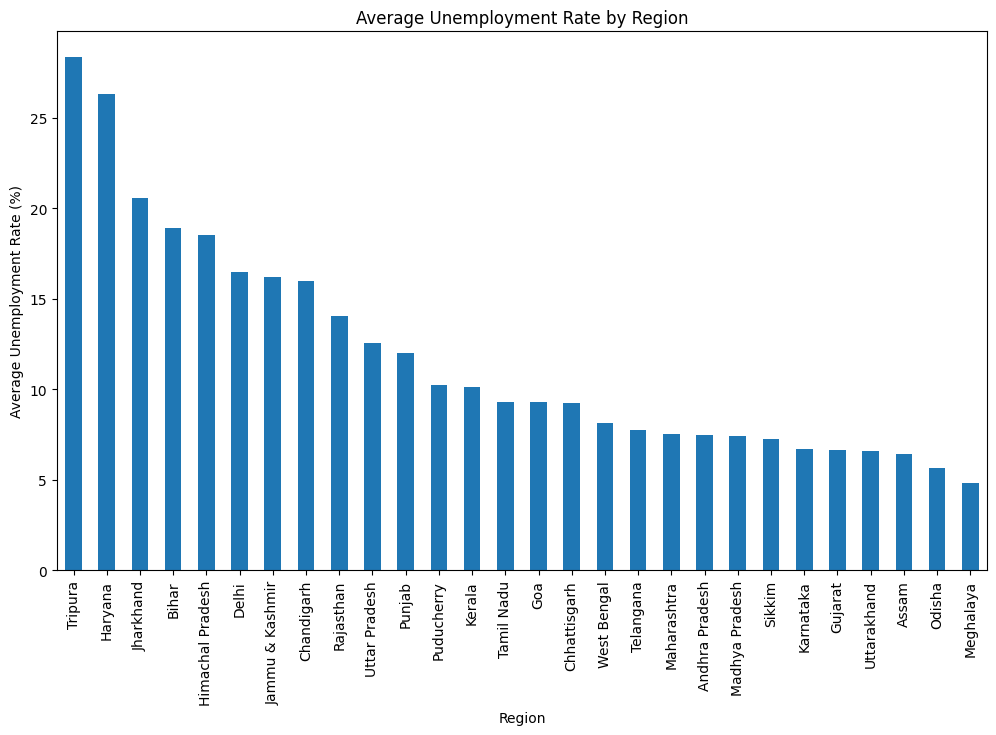

In [16]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

region_avg.plot(kind='bar')

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.show()

The average unemployment rate varies considerably across regions, showing clear regional differences in unemployment levels.

# **Monthly Unemployment Trend**

/tmp/ipykernel_9304/991234114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month


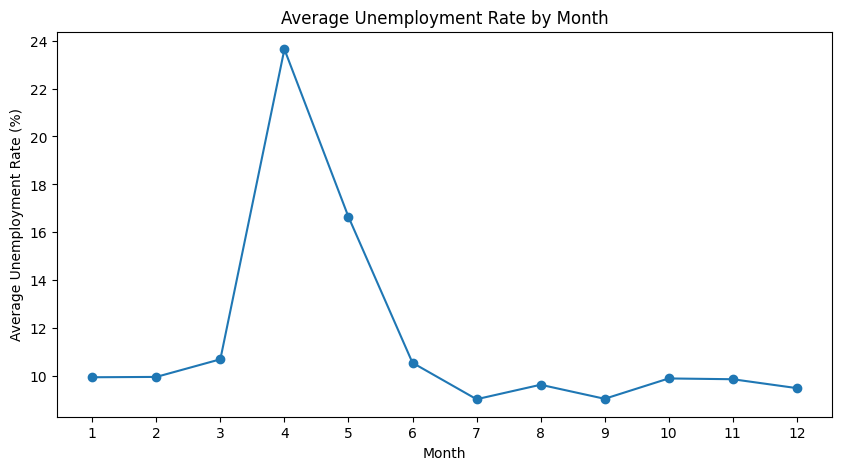

In [17]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10, 5))

monthly_avg.plot(kind='line', marker='o')

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1, 13))

plt.show()

The monthly trend helps identify recurring changes in unemployment rates across different months and reveals possible seasonal patterns.

# **Economic and Social Policy Insights**

New Markdown Cell lo idi pettu:

Economic and Social Policy Insights

1.Regions with higher unemployment rates may require targeted
employment-generation programs.

2.Urban areas showing higher unemployment can benefit from skill-development and job-placement initiatives.

3.Sharp increases during the COVID-19 period highlight the importance of emergency employment and social-support measures.

4.Monthly variations can help policymakers plan employment programs according to periods of higher unemployment.



**Observation:**

The analysis can help identify regions and periods requiring greater attention for employment support, skill development, and social assistance.

# **Conclusion**

The unemployment analysis provided insights into regional, urban-rural, monthly, and COVID-19-related changes in unemployment rates. The visualizations helped identify major trends and variations in unemployment during the analyzed period.